#### 4. ¿Es posible reconstruir la imagen de manera única?

Para que una imagen de 8x8, vectorizada en 64 componentes, pueda reconstruirse de manera única, la matriz de proyección debe tener rango 64. Por el teorema de rango y nulidad, Rango(A)+Dim(Nul(A)=64, por lo que un rango completo implica que el espacio nulo contiene únicamente al vector cero. Si existe un vector no nulo v tal que Av=0, entonces x y x+v producen las mismas mediciones, por lo que la reconstrucción no es única.

#### b)

In [1]:
import numpy as np

from funciones import (N, X_fantoma, xfantoma, matriz_proyeccion,)

In [2]:
#definimos las direcciones:
D2 = [(1,0), (0,1)]

D4 = D2 + [(1,1), (1,-1)]

D7 = D4 + [(2,1), (1,2), (3,1)]

#construimos las matrices:
A2, rayos2 = matriz_proyeccion(8, D2)
A4, rayos4 = matriz_proyeccion(8, D4)
A7, rayos7 = matriz_proyeccion(8, D7)

#calculamos el rango:
rango_A2 = np.linalg.matrix_rank(A2)
rango_A4 = np.linalg.matrix_rank(A4)
rango_A7 = np.linalg.matrix_rank(A7)

#calculamos la dimensión del espacio nulo:
nul_A2 = 64 - rango_A2
nul_A4 = 64 - rango_A4
nul_A7 = 64 - rango_A7

In [3]:
print("A2")
print("Dimensiones:", A2.shape)
print("Rango:", rango_A2)
print("Dimensión del espacio nulo:", nul_A2)
print("Reconstrucción única:", rango_A2 == 64)

print()

print("A4")
print("Dimensiones:", A4.shape)
print("Rango:", rango_A4)
print("Dimensión del espacio nulo:", nul_A4)
print("Reconstrucción única:", rango_A4 == 64)

print()

print("A7")
print("Dimensiones:", A7.shape)
print("Rango:", rango_A7)
print("Dimensión del espacio nulo:", nul_A7)
print("Reconstrucción única:", rango_A7 == 64)

A2
Dimensiones: (16, 64)
Rango: 15
Dimensión del espacio nulo: 49
Reconstrucción única: False

A4
Dimensiones: (46, 64)
Rango: 39
Dimensión del espacio nulo: 25
Reconstrucción única: False

A7
Dimensiones: (119, 64)
Rango: 64
Dimensión del espacio nulo: 0
Reconstrucción única: True


Para cada conjunto de direcciones se construyó su matriz de proyección correspondiente. Luego se calculó el rango y, utilizando el teorema de rango-nulidad, la dimensión del espacio nulo como 64-rango(A). La reconstrucción es única únicamente cuando el rango es 64. Además, si la cantidad de filas es mayor que el rango, existen mediciones redundantes, ya que algunas filas de la matriz no aportan nueva información linealmente independiente.

En $A_2$, la matriz tiene 16 filas y 64 columnas:

$ A_2\in \mathbb{R}^{16\times 64} $

pero su rango es 15. Eso significa que, de las 16 mediciones, solo 15 aportan información linealmente independiente. Hay al menos una medición redundante. Además:

$ \dim(\operatorname{Nul}(A_2))=64-15=49 $

Así que hay un espacio nulo enorme: existen muchísimos vectores v !=0 tales que $A_2v=0$. Por eso no hay reconstrucción única.

En $A_4$:

$ A_4\in \mathbb{R}^{46\times64} $ y $ \operatorname{rango}(A_4)=39 $

O sea, agregamos más direcciones y más rayos, pero de las 46 mediciones solo 39 son independientes. Entonces hay:

$ 46-39=7 $ mediciones redundantes, y $ \dim(\operatorname{Nul}(A_4))=64-39=25 $

Así que todavía hay muchas modificaciones posibles de la imagen que no cambian las mediciones. Por eso tampoco es única.

En $A_7$:

$ A_7\in \mathbb{R}^{119\times64} $ y $ \operatorname{rango}(A_7)=64 $

Acá sí alcanzamos rango columna completo. Entonces:

$ \dim(\operatorname{Nul}(A_7))=64-64=0 $

y por lo tanto:

$ \operatorname{Nul}(A_7)=\{0\} $

Eso significa que no existe ningún cambio no nulo en la imagen que sea invisible para $A_7$. Por eso la reconstrucción sí puede ser única.

Además, en $A_7$ hay muchísimas mediciones redundantes:

$ 119-64=55 $

porque una vez que alcanzamos rango 64, ninguna fila extra puede aumentar el rango más allá de 64.

Al aumentar la cantidad de direcciones, aumenta la cantidad de información independiente disponible sobre la imagen. Para $A_2$ y $A_4$, el rango es menor que 64, por lo que sus espacios nulos tienen dimensión positiva y la reconstrucción no es única. En cambio, $A_7$ tiene rango 64 y espacio nulo trivial, por lo que permite determinar una única imagen. Además, en los tres casos la cantidad de filas supera al rango, lo que indica la presencia de mediciones redundantes.

#### c)


Primero usamos SVD para descomponer:

$$ A_4 = U\Sigma V^T $$

Las últimas filas de $V^T$ asociadas a valores singulares nulos o casi nulos apuntan en direcciones del espacio nulo.

In [4]:
U, S, Vt = np.linalg.svd(A4)

Después tomamos el último vector de $V_t$:

In [5]:
v = Vt[-1]

Ese v debería pertenecer aproximadamente al espacio nulo.

Verificamos:

In [6]:
print("Norma de v:", np.linalg.norm(v))
print("Norma de A4 @ v:", np.linalg.norm(A4 @ v))

Norma de v: 1.0000000000000002
Norma de A4 @ v: 8.875091758778368e-16


Funciona porque:

$$ A_4v\approx 0 $$

entonces v representa un patrón de imagen que el sistema de medición $A_4$ prácticamente no detecta.

Después calculamos las mediciones originales:

In [7]:
X_fantoma = np.array([
[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
[0.0, 0.0, 0.8, 0.3, 0.3, 0.3, 0.0, 0.0],
[0.0, 0.8, 0.8, 0.8, 0.3, 0.3, 0.3, 0.0],
[0.0, 0.3, 0.8, 0.3, 0.3, 0.3, 0.3, 0.0],
[0.0, 0.3, 0.3, 0.3, 0.3, 0.5, 0.3, 0.0],
[0.0, 0.3, 0.3, 0.3, 0.5, 0.5, 0.5, 0.0],
[0.0, 0.0, 0.3, 0.3, 0.3, 0.5, 0.0, 0.0],
[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
], dtype=float)

xfantoma = X_fantoma.reshape(-1)

In [8]:
b4 = A4 @ xfantoma #genera las mediciones correspondientes al fantoma original.

Luego construimos una imagen alternativa

Elegimos algún:

$$ \gamma\neq0 $$

Por ejemplo:

In [9]:
gamma = 1

In [10]:
x_alt = xfantoma + gamma * v

Verificamos que producen las mismas mediciones

In [11]:
b4_alt = A4 @ x_alt

In [12]:
print("Diferencia entre mediciones:", np.linalg.norm(b4 - b4_alt))

Diferencia entre mediciones: 1.18405786683453e-15


Da un valor extremadamente chico, cercano a cero porque:

$ A_4x_{\text{alt}} = A_4(x_{\text{fantoma}}+\gamma v) $

distribuyendo:

$ A_4x_{\text{fantoma}}+\gamma A_4v $

pero como

$ A_4v\approx0 $

queda:

$ A_4x_{\text{alt}} \approx A_4x_{\text{fantoma}} $

Entonces

$ \boxed{b_{4,\text{alt}}\approx b_4} $

aunque:
$x_{alt}$ ​!= $x_{fantoma}​$

In [13]:
X_alt = x_alt.reshape(8, 8)
V_img = v.reshape(8, 8)

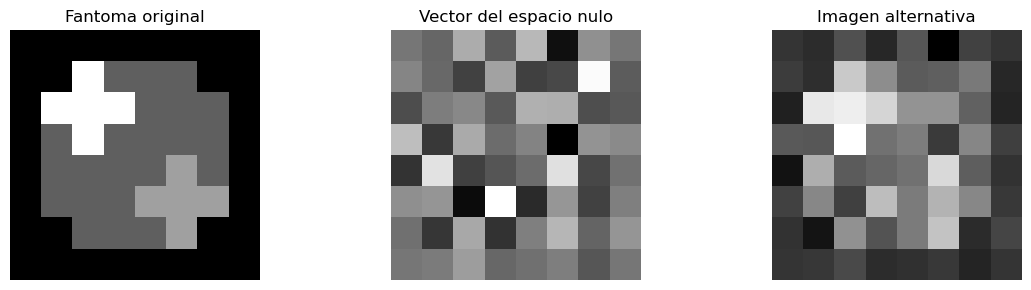

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 3))

plt.subplot(1, 3, 1)
plt.imshow(X_fantoma, cmap="gray")
plt.title("Fantoma original")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(V_img, cmap="gray")
plt.title("Vector del espacio nulo")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(X_alt, cmap="gray")
plt.title("Imagen alternativa")
plt.axis("off")

plt.tight_layout()
plt.show()

La imagen alternativa se ve distinta porque le sumamos una componente del espacio nulo. Sin embargo, esa componente es invisible para $A_4$, ya que al multiplicarla por la matriz de proyección produce aproximadamente cero. Por eso las mediciones no cambian aunque la imagen sí cambie. Esto muestra que $A_4$ no puede distinguir ciertas variaciones de la imagen, por lo que la reconstrucción no es única.